In [1]:
from pathlib import Path
import os
import random
import csv
import time
from collections import defaultdict

import matplotlib.pyplot as plt
import networkx as nx
import community as community_louvain


# =========================
# 1. 基础设置
# =========================

SEED = 42

# 1.0 表示删到所有边都删完；如果太慢，可以改成 0.6
MAX_REMOVE_FRAC = 1.0


# =========================
# 2. 项目路径设置
# =========================
# 目标结构：
# network collapse/
# ├── attack_compare.ipynb
# ├── data/
# │   ├── football.gml
# │   └── karate.gml
# ├── result/
# └── .gitignore

BASE_DIR = Path.cwd()

# 防止你当前目录刚好在 data 里
if BASE_DIR.name.lower() == "data":
    BASE_DIR = BASE_DIR.parent

# 防止 JupyterLab 当前目录还在 C:\Users\86185，而不是 network collapse
if (BASE_DIR / "network collapse").exists():
    BASE_DIR = BASE_DIR / "network collapse"

os.chdir(BASE_DIR)

DATA_DIR = BASE_DIR / "data"
RESULT_DIR = BASE_DIR / "result"

DATA_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)

DATASETS = {
    "football": DATA_DIR / "football.gml",
    "karate": DATA_DIR / "karate.gml",
}


# =========================
# 3. Louvain 社区检测函数
# =========================

def louvain_communities(G, seed=42):
    """
    使用 python-louvain 做 Louvain 社区检测。
    输入：NetworkX 无向图
    输出：list[set]，每个 set 是一个社区的节点集合
    """
    if G.number_of_nodes() == 0:
        return []

    if G.number_of_edges() == 0:
        return [set(G.nodes())]

    partition = community_louvain.best_partition(
        G,
        random_state=seed,
        weight="weight"
    )

    comm_dict = {}
    for node, cid in partition.items():
        comm_dict.setdefault(cid, set()).add(node)

    return list(comm_dict.values())


print("当前项目目录：", BASE_DIR)
print("数据目录：", DATA_DIR)
print("结果目录：", RESULT_DIR)
print("NetworkX 版本：", nx.__version__)

for name, path in DATASETS.items():
    print(name, "->", path, "存在吗：", path.exists())

当前项目目录： C:\Users\86185\network collapse
数据目录： C:\Users\86185\network collapse\data
结果目录： C:\Users\86185\network collapse\result
NetworkX 版本： 2.6.3
football -> C:\Users\86185\network collapse\data\football.gml 存在吗： True
karate -> C:\Users\86185\network collapse\data\karate.gml 存在吗： True


In [5]:
def load_simple_graph(path):
    """
    读取 gml 文件，并统一转成无向、无权、简单图。

    关键修正：
    nx.read_gml(path, label=None)
    有些 gml 文件，比如 karate.gml，没有 label 属性。
    如果不写 label=None，NetworkX 默认会找 label 字段，就会报：
    node #0 has no 'label' attribute
    """
    if not path.exists():
        raise FileNotFoundError(f"找不到文件：{path}\n请把文件放到 data 文件夹里。")

    # 关键：label=None，直接使用 gml 里的 id 作为节点名
    G_raw = nx.read_gml(path, label=None)

    # 统一转成无向、无权、简单图
    G = nx.Graph()
    G.add_nodes_from(G_raw.nodes())
    G.add_edges_from(G_raw.edges())
    G.remove_edges_from(nx.selfloop_edges(G))

    return G

def largest_cc_subgraph(G):
    """
    返回当前网络的 GCC，也就是最大连通分量子图。
    """
    if G.number_of_nodes() == 0:
        return G.copy()

    if G.number_of_edges() == 0:
        return G.copy()

    largest_nodes = max(nx.connected_components(G), key=len)
    return G.subgraph(largest_nodes).copy()


def gcc_ratio(G, original_n):
    """
    计算当前 GCC 相对原始节点数的比例。
    """
    if G.number_of_nodes() == 0:
        return 0

    if G.number_of_edges() == 0:
        # 如果没有边，最大连通分量通常就是单个节点
        return 1 / original_n if original_n > 0 else 0

    largest_nodes = max(nx.connected_components(G), key=len)
    return len(largest_nodes) / original_n


def edge_sort_key(edge):
    """
    用于并列时稳定排序，避免每次结果随机变。
    """
    u, v = edge
    return tuple(sorted((str(u), str(v))))


def choose_degree_product_edge(G):
    """
    M2：选择当前 GCC 中度乘积 k_i * k_j 最大的边。
    每删一条边后重新计算。
    """
    H = largest_cc_subgraph(G)

    if H.number_of_edges() == 0:
        return None

    deg = dict(H.degree())

    return max(
        H.edges(),
        key=lambda e: (deg[e[0]] * deg[e[1]], edge_sort_key(e))
    )


def choose_betweenness_edge(G):
    """
    M5：选择当前 GCC 中边介数最大的边。
    每删一条边后重新计算边介数。
    """
    H = largest_cc_subgraph(G)

    if H.number_of_edges() == 0:
        return None

    bc = nx.edge_betweenness_centrality(
        H,
        normalized=True,
        weight=None
    )

    return max(
        bc.keys(),
        key=lambda e: (bc[e], edge_sort_key(e))
    )


def choose_community_edge(G, mode, seed=SEED):
    """
    M3 / M4：
    每删一条边后，只在当前 GCC 上重新做 Louvain 社区检测。

    mode = "community_size":
        M3：选择 C_i * C_j 最大的社区间边

    mode = "community_internal_div_inter":
        M4：选择 E_i * E_j / E_ij 最大的社区间边
        E_i, E_j：两个社区内部边数
        E_ij：两个社区之间的边数
    """
    H = largest_cc_subgraph(G)

    if H.number_of_edges() == 0:
        return None

    communities = louvain_communities(H, seed=seed)

    # 如果 Louvain 只划出一个社区，就退化为度乘积攻击
    if len(communities) < 2:
        return choose_degree_product_edge(G)

    node_to_comm = {}
    comm_sizes = []

    for cid, comm in enumerate(communities):
        comm_sizes.append(len(comm))
        for node in comm:
            node_to_comm[node] = cid

    internal_edges = [0] * len(communities)
    inter_counts = defaultdict(int)

    # 统计社区内部边数、社区间边数
    for u, v in H.edges():
        cu = node_to_comm[u]
        cv = node_to_comm[v]

        if cu == cv:
            internal_edges[cu] += 1
        else:
            a, b = sorted((cu, cv))
            inter_counts[(a, b)] += 1

    deg = dict(H.degree())
    candidates = []

    for u, v in H.edges():
        cu = node_to_comm[u]
        cv = node_to_comm[v]

        # 只考虑社区间边
        if cu == cv:
            continue

        a, b = sorted((cu, cv))

        if mode == "community_size":
            score = comm_sizes[cu] * comm_sizes[cv]

        elif mode == "community_internal_div_inter":
            denom = inter_counts[(a, b)]
            score = (internal_edges[cu] * internal_edges[cv]) / denom if denom != 0 else 0

        else:
            raise ValueError("未知 mode")

        # 并列时用度乘积辅助排序
        tie_score = deg[u] * deg[v]
        candidates.append((score, tie_score, edge_sort_key((u, v)), (u, v)))

    # 如果没有社区间边，也退化为度乘积攻击
    if not candidates:
        return choose_degree_product_edge(G)

    return max(candidates, key=lambda x: (x[0], x[1], x[2]))[3]


print("基础函数加载完成")

基础函数加载完成


In [3]:
METHODS = [
    ("M1 Random", "random"),
    ("M2 max k_i*k_j", "degree_product"),
    ("M3 max C_i*C_j with Louvain", "community_size"),
    ("M4 max E_i*E_j/E_ij with Louvain", "community_internal_div_inter"),
    ("M5 max edge betweenness", "edge_betweenness"),
]


def simulate_attack(G0, method_key, method_label, seed=SEED, max_remove_frac=MAX_REMOVE_FRAC):
    """
    对一个网络执行某一种攻击，返回每一步的 GCC 比例。
    """
    rng = random.Random(seed)
    G = G0.copy()

    original_n = G.number_of_nodes()
    original_m = G.number_of_edges()
    max_steps = int(original_m * max_remove_frac)

    records = []

    # 第 0 步：还没有删边
    records.append({
        "method": method_label,
        "removed_edges": 0,
        "remove_ratio": 0,
        "gcc_ratio": gcc_ratio(G, original_n),
    })

    # M1 随机攻击：提前打乱所有边
    random_edges = list(G.edges())
    rng.shuffle(random_edges)

    for step in range(1, max_steps + 1):
        if G.number_of_edges() == 0:
            break

        if method_key == "random":
            edge_to_remove = None

            while random_edges:
                e = random_edges.pop()
                if G.has_edge(*e):
                    edge_to_remove = e
                    break

        elif method_key == "degree_product":
            edge_to_remove = choose_degree_product_edge(G)

        elif method_key == "community_size":
            edge_to_remove = choose_community_edge(
                G,
                mode="community_size",
                seed=seed
            )

        elif method_key == "community_internal_div_inter":
            edge_to_remove = choose_community_edge(
                G,
                mode="community_internal_div_inter",
                seed=seed
            )

        elif method_key == "edge_betweenness":
            edge_to_remove = choose_betweenness_edge(G)

        else:
            raise ValueError("未知攻击模式")

        if edge_to_remove is None:
            break

        if G.has_edge(*edge_to_remove):
            G.remove_edge(*edge_to_remove)

        records.append({
            "method": method_label,
            "removed_edges": step,
            "remove_ratio": step / original_m,
            "gcc_ratio": gcc_ratio(G, original_n),
        })

    return records


def save_records_to_csv(records, csv_path):
    """
    保存攻击过程数据。
    """
    fieldnames = ["method", "removed_edges", "remove_ratio", "gcc_ratio"]

    with open(csv_path, "w", newline="", encoding="utf-8-sig") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(records)


def plot_attack_results(records, title, fig_path):
    """
    画五种攻击模式的 GCC 折线图。
    """
    plt.figure(figsize=(9, 6))

    for method_label, _ in METHODS:
        xs = [r["remove_ratio"] for r in records if r["method"] == method_label]
        ys = [r["gcc_ratio"] for r in records if r["method"] == method_label]

        plt.plot(xs, ys, linewidth=2, label=method_label)

    plt.xlabel("Removed edge ratio")
    plt.ylabel("Relative size of GCC")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("图已保存：", fig_path)


print("攻击仿真函数加载完成")

攻击仿真函数加载完成


开始处理网络：football
文件路径： C:\Users\86185\network collapse\data\football.gml
节点数： 115
边数： 613
是否无向： True
是否有自环： False
初始 GCC 比例： 1.0
正在运行：M1 Random
完成：M1 Random，用时 0.10 秒
正在运行：M2 max k_i*k_j
完成：M2 max k_i*k_j，用时 1.39 秒
正在运行：M3 max C_i*C_j with Louvain
完成：M3 max C_i*C_j with Louvain，用时 1.92 秒
正在运行：M4 max E_i*E_j/E_ij with Louvain
完成：M4 max E_i*E_j/E_ij with Louvain，用时 1.77 秒
正在运行：M5 max edge betweenness
完成：M5 max edge betweenness，用时 4.72 秒


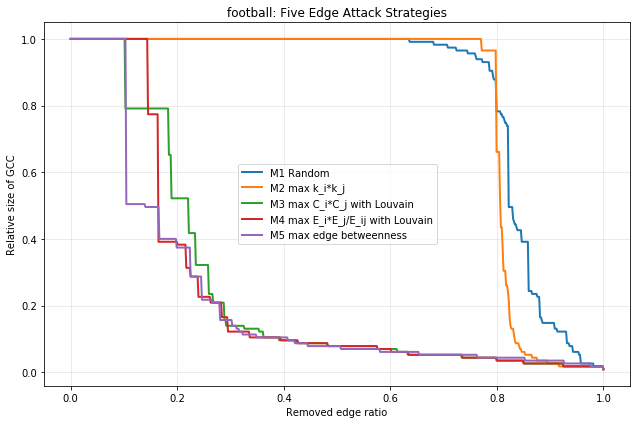

图已保存： C:\Users\86185\network collapse\result\football\football_five_attacks.png
数据已保存： C:\Users\86185\network collapse\result\football\football_five_attacks.csv
图片已保存： C:\Users\86185\network collapse\result\football\football_five_attacks.png
开始处理网络：karate
文件路径： C:\Users\86185\network collapse\data\karate.gml
节点数： 34
边数： 78
是否无向： True
是否有自环： False
初始 GCC 比例： 1.0
正在运行：M1 Random
完成：M1 Random，用时 0.00 秒
正在运行：M2 max k_i*k_j
完成：M2 max k_i*k_j，用时 0.03 秒
正在运行：M3 max C_i*C_j with Louvain
完成：M3 max C_i*C_j with Louvain，用时 0.07 秒
正在运行：M4 max E_i*E_j/E_ij with Louvain
完成：M4 max E_i*E_j/E_ij with Louvain，用时 0.07 秒
正在运行：M5 max edge betweenness
完成：M5 max edge betweenness，用时 0.09 秒


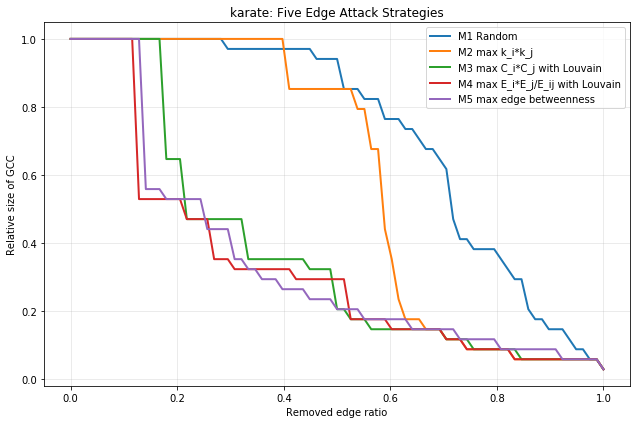

图已保存： C:\Users\86185\network collapse\result\karate\karate_five_attacks.png
数据已保存： C:\Users\86185\network collapse\result\karate\karate_five_attacks.csv
图片已保存： C:\Users\86185\network collapse\result\karate\karate_five_attacks.png
全部完成！结果在 result 文件夹里。


In [6]:
def run_one_dataset(name, path):
    """
    对一个网络执行五种攻击，并保存 CSV 和 PNG。
    """
    print("=" * 70)
    print(f"开始处理网络：{name}")
    print("文件路径：", path)

    G = load_simple_graph(path)

    print("节点数：", G.number_of_nodes())
    print("边数：", G.number_of_edges())
    print("是否无向：", not G.is_directed())
    print("是否有自环：", nx.number_of_selfloops(G) > 0)
    print("初始 GCC 比例：", gcc_ratio(G, G.number_of_nodes()))

    out_dir = RESULT_DIR / name
    out_dir.mkdir(exist_ok=True)

    all_records = []

    for method_label, method_key in METHODS:
        print(f"正在运行：{method_label}")
        t0 = time.time()

        records = simulate_attack(
            G0=G,
            method_key=method_key,
            method_label=method_label,
            seed=SEED,
            max_remove_frac=MAX_REMOVE_FRAC,
        )

        all_records.extend(records)
        elapsed = time.time() - t0
        print(f"完成：{method_label}，用时 {elapsed:.2f} 秒")

    csv_path = out_dir / f"{name}_five_attacks.csv"
    fig_path = out_dir / f"{name}_five_attacks.png"

    save_records_to_csv(all_records, csv_path)

    plot_attack_results(
        all_records,
        title=f"{name}: Five Edge Attack Strategies",
        fig_path=fig_path
    )

    print("数据已保存：", csv_path)
    print("图片已保存：", fig_path)

    return all_records


all_results = {}

for name, path in DATASETS.items():
    all_results[name] = run_one_dataset(name, path)

print("=" * 70)
print("全部完成！结果在 result 文件夹里。")